Prompts used to generate the code are shown below:
I began by asking Github copilot to summarize the matlab script as a whole to check if my understanding of the pipeline was aligned with what the authors did

**"can you please summarize the workflow of this file and the purpose of each step please? "**

it broke it down to 6 steps of workflow and up to step 4 was PCA so next I asked:

**"can you tell me more about steps 1-4. I'd like to convert this script to python"**

the code has some simple shape errors, so I tell the AI that we can't just adjust the arrays to hold flexible sizes since we expect our data to have specific size. So then I say

**"this context will be helpful for creating our PCA, I have the following from a supplementary doc of the paper:" **

**"to create the data visualization shown in Fig. 1b-c, threshold crossing rates were first binned
into 10 ms bins and smoothed by convolving with a Gaussian kernel (sd = 30 ms) to remove high
frequency noise. To find the top 3 PCs used to visualize the neural activity, the smoothed rates
were then compiled into a matrix of dimension N x TC, where N is the number of
microelectrodes (192), T is the number of 10 ms time bins (200), and C is the number of
characters (31). Each row contains the trial-averaged response of a single electrode to each
character, in a time window from -500 ms to 1500 ms around the go cue (the 31 trial-averaged
responses were concatenated together into a single vector). Principal components analysis was
then applied to the columns of this matrix to find the top 3 PCs used for data visualization."**

Its spits out some half correct code to which I say "tell me what assumptions this code has in order to correctly replicate the figure described. Remember we are visualizing the PC scores as a heat map with trials on y axis, time on x axis, and z axis (heat element as the PC score). the visualization PCA should have 3 PCs not 15. Also recall that data have been aligned such that time step 51 corresponds to the go cue signal"

it spits out code to visualize a 3d trajectory plot so i say
"can you walk me through how to make a 2d heat map instead"
that led to our normal PCA visualization.

In [1]:
# to load files from google drive directly, if have shitty laptop
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Install Libraries
!pip install numpy scipy scikit-learn --quiet
# !pip install --upgrade pandas numpy

# Import libraries
import numpy as np
import scipy
import scipy.io #enables uploading of .mat files
import matplotlib.pyplot as plt
# from sklearn.feature_selection import mutual_info_classif #for MI analysis
import math
from scipy import stats as st
from scipy import signal
from scipy import interpolate
from scipy.io import loadmat
import scipy.io as sio
print("Libraries loaded successfully!")

Libraries loaded successfully!


Attempting to load data from .mat file...
Data loaded successfully. Analyzing characters: ['d', 'e', 'm']
Running PCA without time warping...


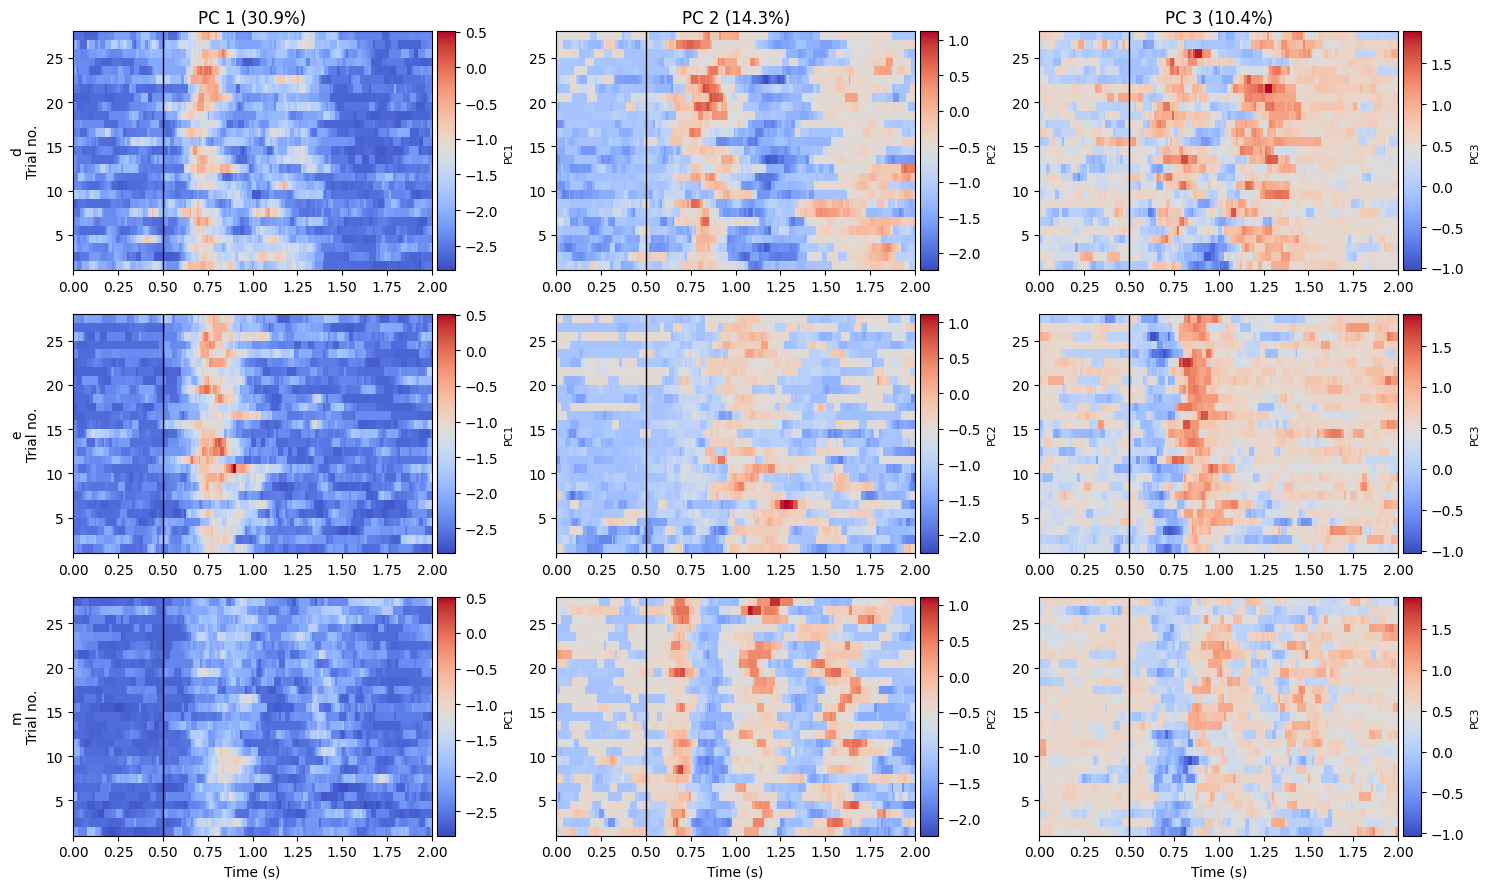

Analysis complete.


In [9]:
### VISUALIZING NORMAL PCA
import numpy as np
from scipy.ndimage import gaussian_filter1d
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import scipy.io as sio
###use this block to visualize PCA
def run_twpca_tf2_on_character(trial_data, n_components=5, warp_reg_scale=0.001, time_reg_scale=1.0, n_iters=200):
    T = trial_data.shape[1]
    D = trial_data.shape[2]

    model = TWPCA_TF2(n_components=n_components, time_points=T, neurons=D)
    model.fit(trial_data, n_iters=n_iters, warp_reg_scale=warp_reg_scale, time_reg_scale=time_reg_scale)
    aligned_trials = model.transform(trial_data)

    return aligned_trials, model  # Return both



def process_neural_data_for_pca(data_dict, characters, apply_time_warping=False):
    """
    Process neural data for PCA visualization, following the original paper's structure.

    Parameters:
    data_dict - Dictionary containing neural data with keys corresponding to different characters
    characters - List of character labels to process

    Returns:
    pc_trajectories - PCA trajectories for each character
    pca_model - Fitted PCA model
    """
    # Constants from the paper
    num_electrodes = 192
    num_time_bins = 200
    num_characters = len(characters)

    # Go cue time step and window definition
    go_cue_bin = 51
    start_bin = go_cue_bin - 50  # -500ms with 10ms bins
    end_bin = start_bin + num_time_bins  # Total 200 bins

    # Step 1: Initialize the N×TC matrix (electrodes × time_bins*characters)
    neural_data_matrix = np.zeros((num_electrodes, num_time_bins * num_characters))

    # Step 2: Process each character
    for c_idx, character in enumerate(characters):
        character_data = data_dict[f'neuralActivityCube_{character}']

        if apply_time_warping:
          print(f"Running TWPCA on character: {character}")
          character_data, model = run_twpca_tf2_on_character(
              character_data,
              n_components=5,
              warp_reg_scale=0.001,
              time_reg_scale=1.0,
              n_iters=50  # 🔽 Lower this (e.g. 50 or 100 instead of 200)
          )
          model_dict[character] = model


        # Average across trials
        trial_avg = np.mean(character_data, axis=0)  # [time, electrodes]

        # Extract time window around go cue
        windowed_data = trial_avg[start_bin:end_bin, :]  # [200 bins, 192 electrodes]

        # Apply Gaussian smoothing (SD=30ms = 3 bins)
        smoothed_data = gaussian_filter1d(windowed_data, sigma=3, axis=0)

        # Place in the neural data matrix (rearranging to have electrodes as rows)
        for e in range(num_electrodes):
            col_start = c_idx * num_time_bins
            col_end = (c_idx + 1) * num_time_bins
            neural_data_matrix[e, col_start:col_end] = smoothed_data[:, e]

    # Step 3: Apply PCA to the columns
    pca = PCA(n_components=3)
    pc_scores = pca.fit_transform(neural_data_matrix.T)  # [TC, 3]

    # Step 4: Reshape PC scores for visualization
    pc_trajectories = np.zeros((num_characters, num_time_bins, 3))
    for c in range(num_characters):
        for t in range(num_time_bins):
            idx = c * num_time_bins + t
            pc_trajectories[c, t, :] = pc_scores[idx, :]

    return pc_trajectories, pca

def visualize_pc_trial_heatmaps_independent_scales(data_dict, characters, pca_model, num_trials=27):
    """
    Create heatmap visualization of PC scores over time for each trial with independent color scales.

    Parameters:
    data_dict - Dictionary containing neural data with keys corresponding to different characters
    characters - List of character labels to process
    pca_model - Fitted PCA model
    num_trials - Number of trials to show (maximum)
    """
    # Constants from the original code
    num_time_bins = 200
    go_cue_bin = 51
    start_bin = go_cue_bin - 50  # -500ms with 10ms bins
    end_bin = start_bin + num_time_bins  # Total 200 bins

    # Create figure with subplots - one subplot per character, one column per PC
    num_chars = len(characters)
    num_pcs = 3

    fig, axes = plt.subplots(num_chars, num_pcs, figsize=(15, 3*num_chars),
                            gridspec_kw={'width_ratios': [1] * num_pcs})

    # Handle the case when there's only one character
    if num_chars == 1:
        axes = [axes]

    # Time in seconds (assuming 10ms bins from the original code)
    time_in_sec = np.linspace(0, num_time_bins * 0.01, num_time_bins)

    # Go cue time
    go_cue_time = time_in_sec[50]  # 0.5s if bins are 10ms

    # Process each character
    all_pc_scores = []

    # Process each character to get PC scores
    for c_idx, character in enumerate(characters):
        # Load neural data for this character
        character_data = data_dict[f'neuralActivityCube_{character}']

        # Limit to the number of trials we want to display
        actual_trials = min(character_data.shape[0], num_trials)

        # Initialize array for trial PC scores
        trial_pc_scores = np.zeros((actual_trials, num_time_bins, num_pcs))

        # Process each trial
        for trial in range(actual_trials):
            # Extract time window around go cue for this trial
            trial_data = character_data[trial, start_bin:end_bin, :]  # [200 bins, 192 electrodes]

            # Apply Gaussian smoothing (SD=30ms = 3 bins)
            smoothed_data = gaussian_filter1d(trial_data, sigma=3, axis=0)

            # Project onto PC space
            for t in range(num_time_bins):
                time_point_data = smoothed_data[t, :]
                pc_projection = pca_model.transform([time_point_data])[0]
                trial_pc_scores[trial, t, :] = pc_projection[:num_pcs]

        all_pc_scores.append(trial_pc_scores)

    # Collect all data for each PC separately to calculate independent color scales
    pc_data_by_component = [[] for _ in range(num_pcs)]
    for pc_scores in all_pc_scores:
        for pc_idx in range(num_pcs):
            pc_data_by_component[pc_idx].append(pc_scores[:, :, pc_idx])

    # Calculate min/max for each PC independently
    vmin_by_pc = []
    vmax_by_pc = []
    for pc_idx in range(num_pcs):
        all_data_this_pc = np.concatenate([d.flatten() for d in pc_data_by_component[pc_idx]])
        vmin_by_pc.append(np.min(all_data_this_pc))
        vmax_by_pc.append(np.max(all_data_this_pc))

    # Define colormap
    cmap = plt.cm.coolwarm

    # Create heatmaps for each character and PC
    for c_idx, character in enumerate(characters):
        character_data = data_dict[f'neuralActivityCube_{character}']
        actual_trials = min(character_data.shape[0], num_trials)

        # Get the processed PC scores for this character
        trial_pc_scores = all_pc_scores[c_idx]

        for pc_idx in range(num_pcs):
            if num_chars == 1:
                ax = axes[0][pc_idx]
            else:
                ax = axes[c_idx][pc_idx]

            # Extract data for this PC
            pc_data = trial_pc_scores[:, :, pc_idx]

            # Create heatmap - using PC-specific min/max values
            im = ax.imshow(pc_data, aspect='auto', origin='lower',
                          extent=[time_in_sec[0], time_in_sec[-1], 1, actual_trials+1],
                          cmap=cmap, interpolation='nearest',
                          vmin=vmin_by_pc[pc_idx], vmax=vmax_by_pc[pc_idx])
            # im = plt.imshow(pc_data, aspect='auto', origin='lower', extent=[time_in_sec[0], time_in_sec[-1], 1, actual_trials+1],
            #            cmap=cmap, interpolation='nearest')

            # Add vertical line for go cue
            ax.axvline(x=go_cue_time, color='black', linestyle='-', linewidth=1)

            # Set labels
            if c_idx == 0:
                ax.set_title(f'PC {pc_idx+1}', fontsize=12)

            if pc_idx == 0:
                # Add character label to y-axis
                ax.set_ylabel(f'{character}\nTrial no.', fontsize=10)

            if c_idx == num_chars-1:
                ax.set_xlabel('Time (s)', fontsize=10)

            # Add individual colorbar for each PC
            divider = make_axes_locatable(ax)
            cax = divider.append_axes("right", size="5%", pad=0.05)
            cbar = plt.colorbar(im, cax=cax)
            cbar.set_label(f'PC{pc_idx+1}', fontsize=8)

    # Add variance explained if PCA model is provided
    if pca_model is not None and num_chars > 0:
        var_ratios = pca_model.explained_variance_ratio_
        for pc_idx in range(num_pcs):
            if num_chars == 1:
                axes[0][pc_idx].set_title(f'PC {pc_idx+1} ({var_ratios[pc_idx]:.1%})', fontsize=12)
            else:
                axes[0][pc_idx].set_title(f'PC {pc_idx+1} ({var_ratios[pc_idx]:.1%})', fontsize=12)

    plt.tight_layout()
    plt.show()

    return fig

def main():
    try:
        # Try to load data from MATLAB file
        print("Attempting to load data from .mat file...")
        # CHANGE THIS PATH TO YOUR LAPTOP
        data_dict = sio.loadmat('/content/drive/MyDrive/Emory_Year_2/COMP NEURO/t5.2019.05.08_singleLetters.mat')

        # Extract characters (replace with your actual characters)
        characters = ['d', 'e', 'm']

        print(f"Data loaded successfully. Analyzing characters: {characters}")

    except Exception as e:
        print(f"Error loading data: {e}")
        print("Generating random data for testing...")

        # Generate random test data
        num_trials = 27
        num_time = 300  # Total time bins
        num_electrodes = 192

        data_dict = {}
        characters = ['d', 'e', 'm']

        for char in characters:
            # Generate random data more efficiently
            data = np.random.randn(num_trials, num_time, num_electrodes) * 0.5

            # Add a simulated response pattern more efficiently using vectorization
            for trial in range(num_trials):
                peak_time = 100 + int(np.random.normal(0, 10))
                # Create time array
                t_array = np.arange(num_time)
                # Calculate Gaussian pattern for all time points at once
                gaussian_pattern = 2.0 * np.exp(-0.01 * (t_array - peak_time)**2)
                # Add the pattern to all electrodes for this trial
                for e in range(num_electrodes):
                    data[trial, :, e] += gaussian_pattern

            data_dict[f'neuralActivityCube_{char}'] = data

    print("Running PCA without time warping...")
    pc_raw, pca_raw = process_neural_data_for_pca(data_dict, characters, apply_time_warping=False)
    visualize_pc_trial_heatmaps_independent_scales(data_dict, characters, pca_raw)

    print("Analysis complete.")
    return pc_raw, pca_raw




# Run the script when executed directly
if __name__ == "__main__":
    main()

the reason I have two scripts for visualizing is because I initially tried to modify the newer time warping function so that I could have it more closely match the authors original one. However, I was unsuccesful so I just had this function only apply time warping if time warping is set to True. All this function is doing is visualizing the PCA in the same way as the above function but handling naming differences in the variables from the WarpedCube file (containing time warped data) vs singleLetters file (containing un warped data).

Loading time-warped data...
Performing PCA on aligned data...
Visualizing PCA trajectories...


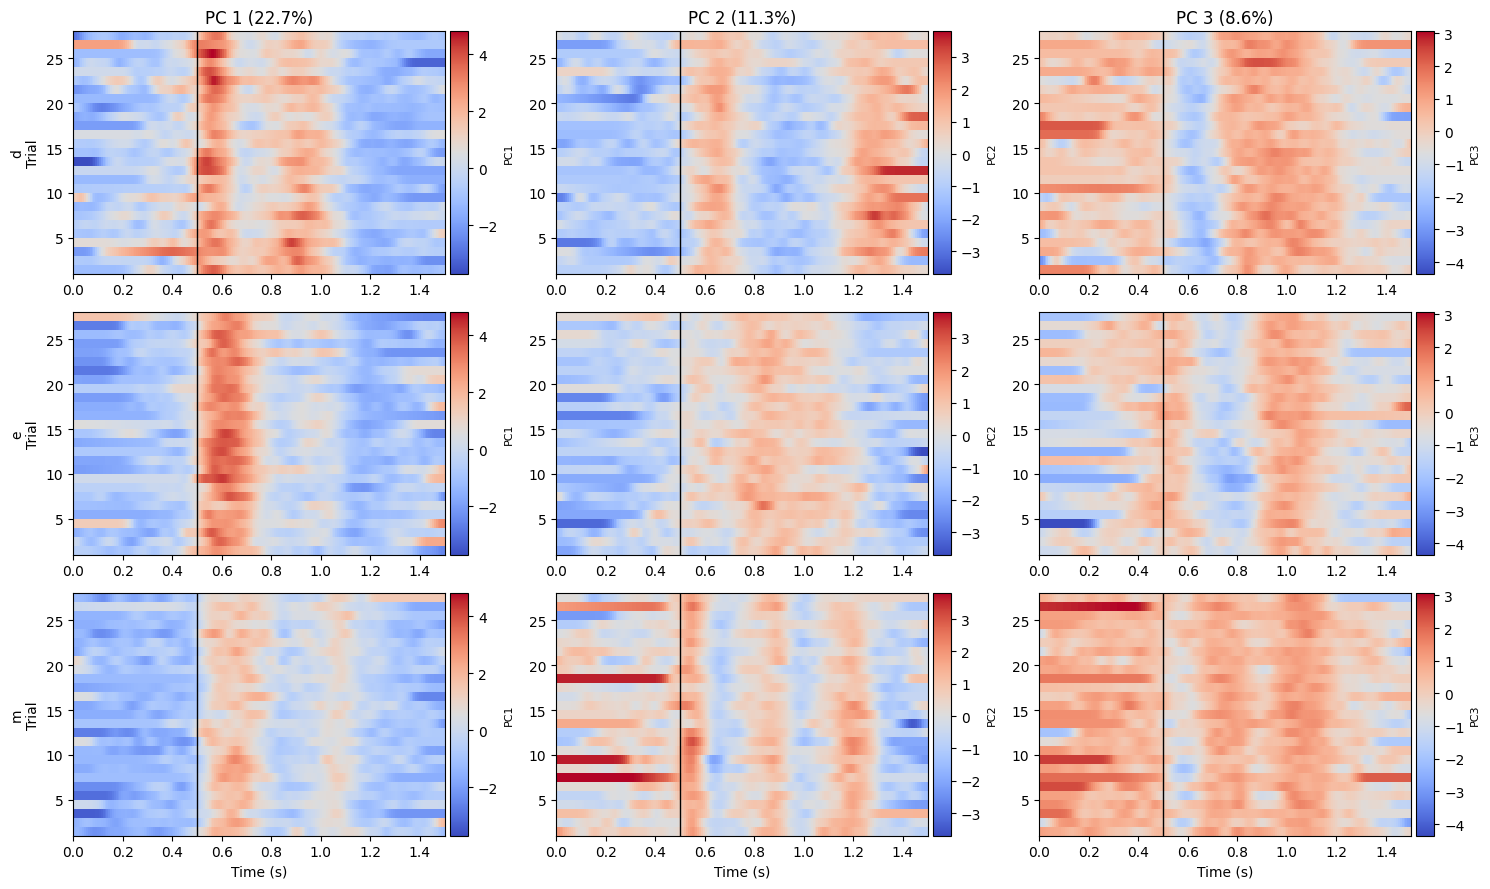

Done.


In [11]:
#### VISUALIZING TIME WARPED DATA ONTO A PCA
import numpy as np
from scipy.ndimage import gaussian_filter1d
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import scipy.io as sio

def process_warped_data_for_pca(data_dict, characters):
    num_electrodes = 192
    num_time_bins = 200
    neural_data_matrix = np.zeros((num_electrodes, num_time_bins * len(characters)))

    for c_idx, character in enumerate(characters):
        char_data = data_dict[character]  # shape: [K, T, N]
        trial_avg = np.mean(char_data, axis=0)  # shape: [T, N]
        # Ensure we have exactly 200 bins (truncate or pad if needed)
        smoothed = gaussian_filter1d(trial_avg, sigma=3, axis=0)
        if smoothed.shape[0] > num_time_bins:
            smoothed = smoothed[:num_time_bins, :]
        elif smoothed.shape[0] < num_time_bins:
            pad_len = num_time_bins - smoothed.shape[0]
            smoothed = np.pad(smoothed, ((0, pad_len), (0, 0)), mode='edge')  # pad with edge values

        for e in range(num_electrodes):
            col_start = c_idx * num_time_bins
            col_end = (c_idx + 1) * num_time_bins
            neural_data_matrix[e, col_start:col_end] = smoothed[:, e]

    pca = PCA(n_components=3)
    pc_scores = pca.fit_transform(neural_data_matrix.T)

    pc_trajectories = np.zeros((len(characters), num_time_bins, 3))
    for c in range(len(characters)):
        for t in range(num_time_bins):
            idx = c * num_time_bins + t
            pc_trajectories[c, t, :] = pc_scores[idx, :]

    return pc_trajectories, pca

def main():
    characters = ['d', 'e', 'm']

    ## CHANGE THIS PATH TO YOUR LAPTOP
    mat_path = '/content/drive/MyDrive/Emory_Year_2/COMP NEURO/t5.2019.05.08_warpedCubes_3.mat'

    print("Loading time-warped data...")
    data_dict = sio.loadmat(mat_path)

    # Extract character data (keys are just 'a', 'b', etc., not 'neuralActivityCube_a')
    warped_data_dict = {char: data_dict[char] for char in characters}

    print("Performing PCA on aligned data...")
    pc_trajectories, pca_model = process_warped_data_for_pca(warped_data_dict, characters)

    print("Visualizing PCA trajectories...")
    visualize_pc_trial_heatmaps_independent_scales(warped_data_dict, characters, pca_model)

    print("Done.")

def visualize_pc_trial_heatmaps_independent_scales(data_dict, characters, pca_model, num_trials=27):
    num_time_bins = 200
    num_chars = len(characters)
    num_pcs = 3

    #time_in_sec = np.linspace(0, num_time_bins * 0.01, num_time_bins) ## original settings we used for plots
    time_in_sec = np.linspace(0, 1.5, num_time_bins)
    go_cue_time = 0.5
    # go_cue_time = time_in_sec[50]  # assumed 500 ms. ## original

    fig, axes = plt.subplots(num_chars, num_pcs, figsize=(15, 3 * num_chars),
                             gridspec_kw={'width_ratios': [1] * num_pcs})

    if num_chars == 1:
        axes = [axes]

    all_pc_scores = []
    for c_idx, character in enumerate(characters):
        character_data = data_dict[character]
        actual_trials = min(character_data.shape[0], num_trials)
        trial_pc_scores = np.zeros((actual_trials, num_time_bins, num_pcs))

        for trial in range(actual_trials):
            smoothed = gaussian_filter1d(character_data[trial, :, :], sigma=3, axis=0)
            for t in range(num_time_bins):
                trial_pc_scores[trial, t, :] = pca_model.transform([smoothed[t]])[0]

        all_pc_scores.append(trial_pc_scores)

    pc_data_by_component = [[] for _ in range(num_pcs)]
    for pc_scores in all_pc_scores:
        for pc_idx in range(num_pcs):
            pc_data_by_component[pc_idx].append(pc_scores[:, :, pc_idx])

    vmin_by_pc = []
    vmax_by_pc = []
    for pc_idx in range(num_pcs):
        all_data = np.concatenate([d.flatten() for d in pc_data_by_component[pc_idx]])
        vmin_by_pc.append(np.min(all_data))
        vmax_by_pc.append(np.max(all_data))

    cmap = plt.cm.coolwarm

    for c_idx, character in enumerate(characters):
        character_data = data_dict[character]
        actual_trials = min(character_data.shape[0], num_trials)
        trial_pc_scores = all_pc_scores[c_idx]

        for pc_idx in range(num_pcs):
            ax = axes[0][pc_idx] if num_chars == 1 else axes[c_idx][pc_idx]
            pc_data = trial_pc_scores[:, :, pc_idx]

            im = ax.imshow(pc_data, aspect='auto', origin='lower',
                           extent=[time_in_sec[0], time_in_sec[-1], 1, actual_trials + 1],
                           cmap=cmap, interpolation='nearest',
                           vmin=vmin_by_pc[pc_idx], vmax=vmax_by_pc[pc_idx])

            ax.axvline(x=go_cue_time, color='black', linestyle='-', linewidth=1)

            if c_idx == 0:
                ax.set_title(f'PC {pc_idx + 1}', fontsize=12)
            if pc_idx == 0:
                ax.set_ylabel(f'{character}\nTrial', fontsize=10)
            if c_idx == num_chars - 1:
                ax.set_xlabel('Time (s)', fontsize=10)

            divider = make_axes_locatable(ax)
            cax = divider.append_axes("right", size="5%", pad=0.05)
            cbar = plt.colorbar(im, cax=cax)
            cbar.set_label(f'PC{pc_idx + 1}', fontsize=8)

    if pca_model is not None and num_chars > 0:
        var_ratios = pca_model.explained_variance_ratio_
        for pc_idx in range(num_pcs):
            title = f'PC {pc_idx+1} ({var_ratios[pc_idx]:.1%})'
            if num_chars == 1:
                axes[0][pc_idx].set_title(title, fontsize=12)
            else:
                axes[0][pc_idx].set_title(title, fontsize=12)

    plt.tight_layout()
    plt.show()
    return fig

if __name__ == "__main__":
    main()
